# QUESTION 2 ,B

In [1]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np

data = {
    "learner_id": [101, 101, 102, 103],
    "course_title": ["Python", "Data Science", "Python", "SQL"],
    "category": [" Programming ", "DATA SCIENCE", "programming", " Database "],
    "rating": [5.0, np.nan, 4.0, np.nan]
}

df = pd.DataFrame(data)

print(df)

# Remove duplicates
df = df.drop_duplicates()

# Standardise categories
df["category"] = df["category"].str.strip().str.lower()

# Handle missing ratings
df["rating_missing"] = df["rating"].isna().astype(int)
df["rating"] = df["rating"].fillna(df["rating"].median())

# Create a behavioural feature
df["courses_interacted"] = df.groupby("learner_id")["course_title"].transform("count")

print(df)


   learner_id  course_title       category  rating
0         101        Python   Programming      5.0
1         101  Data Science   DATA SCIENCE     NaN
2         102        Python    programming     4.0
3         103           SQL      Database      NaN
   learner_id  course_title      category  rating  rating_missing  \
0         101        Python   programming     5.0               0   
1         101  Data Science  data science     4.5               1   
2         102        Python   programming     4.0               0   
3         103           SQL      database     4.5               1   

   courses_interacted  
0                   2  
1                   2  
2                   1  
3                   1  


# QUESTION 3,C

In [2]:
data = { "age": [20, np.nan, 25],"rating": [5.0, 4.0, np.nan],"category": ["Programming", np.nan, "Data Science"]}
df = pd.DataFrame(data)
print("Original data:")
print(df)

def handle_missing(df, numerical_cols, categorical_cols):
    df = df.copy()

    for col in numerical_cols:
        df[col + "_missing"] = df[col].isna().astype(int)
        df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")

    return df
# Specify columns
numerical_cols = ["age", "rating"]
categorical_cols = ["category"]
# Apply function
df = handle_missing(df, numerical_cols, categorical_cols)
print("\nAfter handling missing values:")
print(df)


Original data:
    age  rating      category
0  20.0     5.0   Programming
1   NaN     4.0           NaN
2  25.0     NaN  Data Science

After handling missing values:
    age  rating      category  age_missing  rating_missing
0  20.0     5.0   Programming            0               0
1  22.5     4.0       Unknown            1               0
2  25.0     4.5  Data Science            0               1


# QUESTION 4,C

# OBED IMBAHAFI -25094775

In [3]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.DataFrame({
    "age":[25,34,45,29,52],
    "expenditure":[120,250,180,300,150],
    "subscription":["Basic","Premium","Basic","Premium","Basic"],
    "region":["East","West","North","East","South"]
})

X = ColumnTransformer([
    ("num", StandardScaler(), ["age","expenditure"]),
    ("cat", OneHotEncoder(sparse_output=False), ["subscription","region"])
])

X_model = X.fit_transform(df)

print(pd.DataFrame(X_model).round(2))
print("Original features:", df.shape[1])
print("Model-ready features:", X_model.shape[1])


      0     1    2    3    4    5    6    7
0 -1.19 -1.21  1.0  0.0  1.0  0.0  0.0  0.0
1 -0.30  0.76  0.0  1.0  0.0  0.0  0.0  1.0
2  0.80 -0.30  1.0  0.0  0.0  1.0  0.0  0.0
3 -0.80  1.51  0.0  1.0  1.0  0.0  0.0  0.0
4  1.49 -0.76  1.0  0.0  0.0  0.0  1.0  0.0
Original features: 4
Model-ready features: 8


# QUESTION 4, C

In [4]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Dummy data
df = pd.DataFrame({"patient_id": [1,1,2,2,3,3,4,4,5,5],"admission_date": [ "2024-01-01","2024-02-01","2024-01-05","2024-03-01","2024-01-10","2024-04-01",
        "2024-02-10","2024-05-01","2024-03-10","2024-06-01"],"age": [25,25,40,40,35,35,50,50,28,28]})

df["admission_date"] = pd.to_datetime(df["admission_date"])
df = df.sort_values("admission_date")

# 80% train/validation, 20% test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_val_idx, test_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

# 75% train, 25% validation
splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

train_idx, val_idx = next(
    splitter_val.split(train_val_df, groups=train_val_df["patient_id"])
)

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 6
Validation: 2
Test: 2


# QUESTION 5 , D

In [5]:
from sklearn.model_selection import GroupShuffleSplit

# Dummy data
df = pd.DataFrame({
    "patient_id": [1,1,2,2,3,3,4,4,5,5],
    "admission_date": [
        "2024-01-01","2024-02-01",
        "2024-01-05","2024-03-01",
        "2024-01-10","2024-04-01",
        "2024-02-10","2024-05-01",
        "2024-03-10","2024-06-01"
    ],
    "age": [25,25,40,40,35,35,50,50,28,28]
})

df["admission_date"] = pd.to_datetime(df["admission_date"])
df = df.sort_values("admission_date")

# 80% train/validation, 20% test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_val_idx, test_idx = next(
    splitter.split(df, groups=df["patient_id"])
)

train_val_df = df.iloc[train_val_idx]
test_df = df.iloc[test_idx]

# 75% train, 25% validation
splitter_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

train_idx, val_idx = next(
    splitter_val.split(train_val_df, groups=train_val_df["patient_id"])
)

train_df = train_val_df.iloc[train_idx]
val_df = train_val_df.iloc[val_idx]

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 6
Validation: 2
Test: 2


# QUESTION 6

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M       47 non-null     float64
 1   So      47 non-null     int64  
 2   Ed      47 non-null     float64
 3   Po1     47 non-null     float64
 4   Po2     47 non-null     float64
 5   LF      47 non-null     float64
 6   M.F     47 non-null     float64
 7   Pop     47 non-null     int64  
 8   NW      47 non-null     float64
 9   U1      47 non-null     float64
 10  U2      47 non-null     float64
 11  Wealth  47 non-null     int64  
 12  Ineq    47 non-null     float64
 13  Prob    47 non-null     float64
 14  Time    47 non-null     float64
 15  Crime   47 non-null     int64  
dtypes: float64(12), int64(4)
memory usage: 6.0 KB


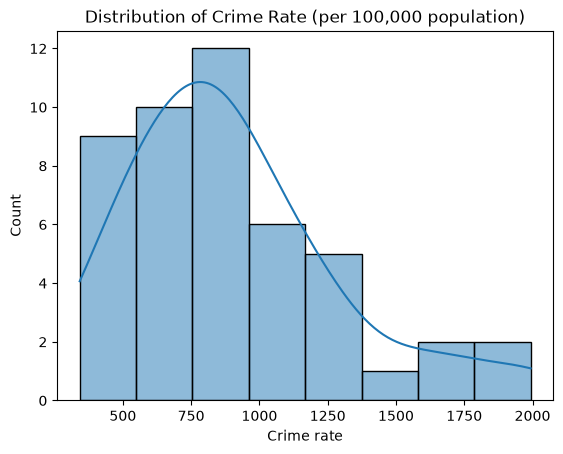

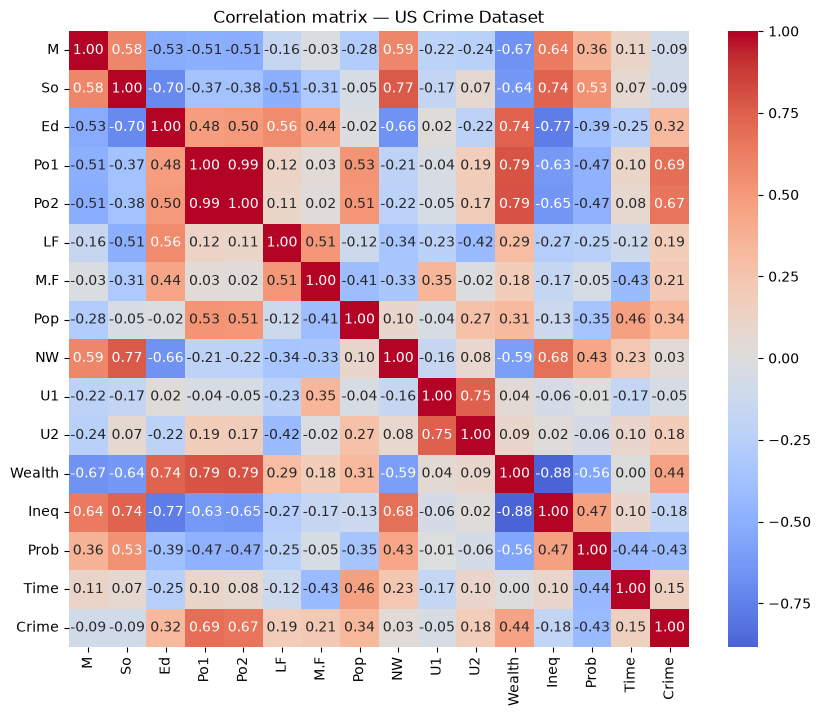

Crime     1.000000
Po1       0.687604
Po2       0.666714
Wealth    0.441320
Prob     -0.427422
Pop       0.337474
Ed        0.322835
M.F       0.213914
LF        0.188866
Ineq     -0.179024
U2        0.177321
Time      0.149866
So       -0.090637
M        -0.089472
U1       -0.050478
NW        0.032599
Name: Crime, dtype: float64
Po1 coefficient (Po1 and Po2 both included): 566.87
Po1 coefficient (Po2 removed):                283.8


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset (tab-separated file)
df = pd.read_csv("uscrime.txt", sep="\t")

# Look at the first few rows
df.head()
# Check the shape (47 states, 16 columns) and column info
#print("Rows, columns:", df.shape)
df.info()
# Check for missing values
df.isna().sum()
# Summary statistics for Crime
df["Crime"].describe()
# Distribution of the target variable
sns.histplot(df["Crime"], kde=True)
plt.title("Distribution of Crime Rate (per 100,000 population)")
plt.xlabel("Crime rate")
plt.show()
# Correlation matrix for all variables
corr = df.corr()

# Show it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — US Crime Dataset")
plt.show()
# Rank all predictors by how strongly they correlate with Crime
print(corr["Crime"].sort_values(key=abs, ascending=False))

# Look at the correlation between predictors only (exclude the target)
predictor_corr = df.drop(columns=["Crime"]).corr()

# Find pairs of variables with a strong correlation (above 0.7, ignoring the diagonal)
strong_pairs = (
    predictor_corr.where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
strong_pairs[strong_pairs.abs() > 0.7]

# Variance Inflation Factor (VIF) - a formal way to measure multicollinearity
# A VIF above ~5-10 usually signals a problem.
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=["Crime"])   # all predictors
X_const = add_constant(X)        # VIF calculation needs a constant column

vif_table = pd.DataFrame({
    "feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})

# Drop the constant row and sort by VIF, highest first
vif_table = vif_table[vif_table["feature"] != "const"].sort_values("VIF", ascending=False)
vif_table

# Standardise all predictors so coefficients are comparable
X_all = df.drop(columns=["Crime"])
X_scaled = StandardScaler().fit_transform(X_all)
y = df["Crime"]

# Model 1: using ALL predictors (including both Po1 and Po2)
model_all = LinearRegression().fit(X_scaled, y)
coef_all = pd.Series(model_all.coef_, index=X_all.columns)

# Model 2: drop the duplicate variable Po2
X_reduced = df.drop(columns=["Crime", "Po2"])
X_reduced_scaled = StandardScaler().fit_transform(X_reduced)
model_reduced = LinearRegression().fit(X_reduced_scaled, y)
coef_reduced = pd.Series(model_reduced.coef_, index=X_reduced.columns)

# Compare the Po1 coefficient in both models
print("Po1 coefficient (Po1 and Po2 both included):", round(coef_all["Po1"], 2))
print("Po1 coefficient (Po2 removed):               ", round(coef_reduced["Po1"], 2))

# QUESTION 7

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   observation_id             1500 non-null   int64  
 1   journey_distance_km        1500 non-null   float64
 2   traffic_index              1500 non-null   float64
 3   time_of_day_hours          1500 non-null   float64
 4   weather_score              1500 non-null   float64
 5   road_slope_pct             1500 non-null   float64
 6   road_type                  1500 non-null   str    
 7   previous_journey_time_min  1500 non-null   float64
 8   traffic_proxy              1500 non-null   float64
 9   distance_proxy             1500 non-null   float64
 10  average_speed_kmh          1500 non-null   float64
 11  driver_experience_years    1500 non-null   float64
 12  passenger_rating           1500 non-null   float64
 13  random_noise_feature       1500 non-null   float64
 14  eta

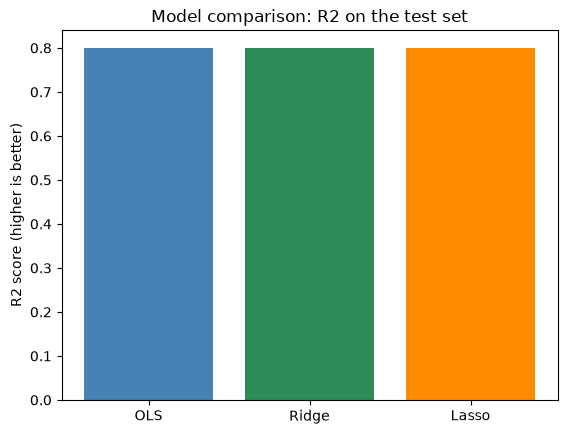

,Feature,Lasso coefficient
0,journey_distance_km,8.499141
1,traffic_index,6.220318
13,road_type_highway,-2.992079
12,road_type_express,-2.322269
3,weather_score,1.736650
14,road_type_local,1.502861
5,previous_journey_time_min,1.022551
4,road_slope_pct,0.651818
11,random_noise_feature,-0.031967
9,driver_experience_years,0.021574


In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load the dataset
df = pd.read_csv("synthetic_ETA.csv")

# Look at the first few rows
df.head()
# Check the shape and column info
#print("Rows, columns:", df.shape)
df.info()
# Check for missing values
df.isna().sum()
# Target variable
y = df["eta_minutes"]

# Features: drop the ID column and the target column
X = df.drop(columns=["observation_id", "eta_minutes"])

# Separate numerical and categorical column names
categorical_cols = ["road_type"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Numerical columns:", numerical_cols)
# ColumnTransformer applies a different transformation to each group of columns
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),          # scale numerical columns
    ("cat", OneHotEncoder(drop="first"), categorical_cols)  # one-hot encode road_type
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
# Dictionary of the three models we want to compare
models = {
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}

# Store the fitted pipelines here so we can reuse them later
fitted_pipelines = {}

for name, model in models.items():
    # Combine preprocessing + model into a single pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    # Train (fit) the pipeline on the training data
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

print("All three models trained.")
results = []

results = []

for name, pipe in fitted_pipelines.items():
    # Predict on the test set
    y_pred = pipe.predict(X_test)

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Convert results to a table
results_df = pd.DataFrame(results)

# Print the table
print(results_df.to_string(index=False))


# Put the results in a table for easy comparison
results_df = pd.DataFrame(results).round(3)
results_df
# Simple bar chart to visually compare R2 scores


plt.bar(results_df["Model"], results_df["R2"], color=["steelblue", "seagreen", "darkorange"])
plt.ylabel("R2 score (higher is better)")
plt.title("Model comparison: R2 on the test set")
plt.show()
# Get the feature names after preprocessing (numerical + one-hot encoded categories)
feature_names = numerical_cols + list(
    fitted_pipelines["Lasso"]["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
)

# Get the Lasso model's coefficients
lasso_coefs = fitted_pipelines["Lasso"]["model"].coef_

# Put them in a table, sorted by size (largest effect first)
coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Lasso coefficient": lasso_coefs
}).sort_values("Lasso coefficient", key=abs, ascending=False)

coef_table

<Figure size 800x500 with 0 Axes>

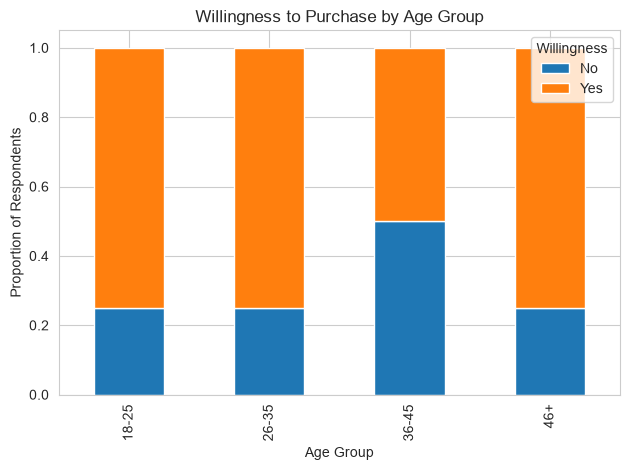

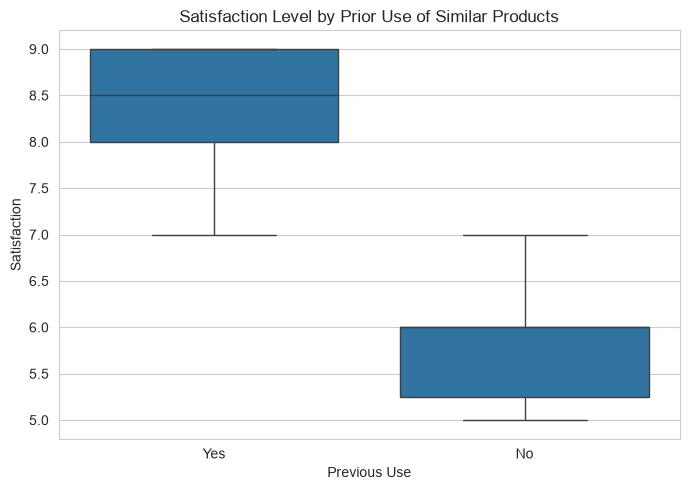

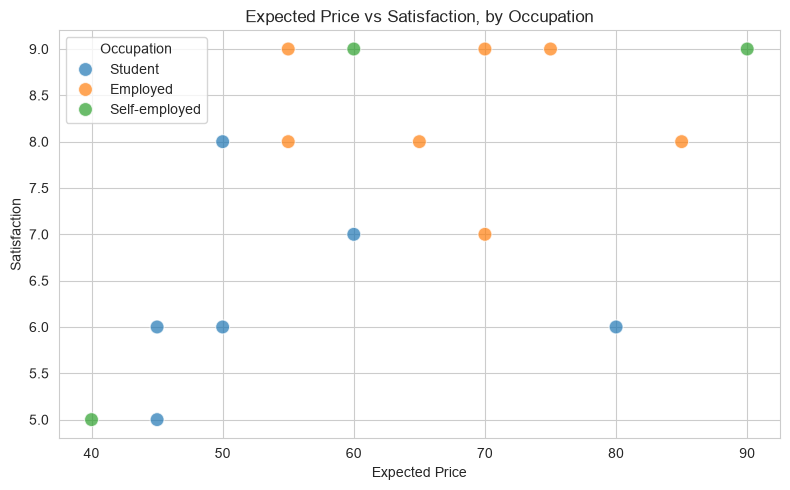

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Create dummy survey data
# -----------------------------

data = {
    "age_group": [
        "18-25", "18-25", "18-25", "18-25",
        "26-35", "26-35", "26-35", "26-35",
        "36-45", "36-45", "36-45", "36-45",
        "46+", "46+", "46+", "46+"
    ],
    "willingness_to_purchase": [
        "Yes", "Yes", "No", "Yes",
        "Yes", "No", "Yes", "Yes",
        "No", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes"
    ],
    "previous_use": [
        "Yes", "No", "Yes", "No",
        "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "No",
        "Yes", "No", "Yes", "Yes"
    ],
    "satisfaction": [
        8, 7, 9, 6,
        9, 8, 6, 9,
        5, 8, 9, 6,
        8, 5, 9, 7
    ],
    "expected_price": [
        50, 60, 55, 45,
        70, 65, 80, 75,
        40, 55, 60, 50,
        85, 45, 90, 70
    ],
    "occupation": [
        "Student", "Student", "Employed", "Student",
        "Employed", "Employed", "Student", "Employed",
        "Self-employed", "Employed", "Self-employed", "Student",
        "Employed", "Student", "Self-employed", "Employed"
    ]
}

df = pd.DataFrame(data)

# -----------------------------
# 1. Categorical vs categorical
# -----------------------------

plt.figure(figsize=(8, 5))

pd.crosstab(
    df["age_group"],
    df["willingness_to_purchase"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Willingness to Purchase by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion of Respondents")
plt.legend(title="Willingness")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Numerical vs categorical
# -----------------------------

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="previous_use",
    y="satisfaction"
)

plt.title("Satisfaction Level by Prior Use of Similar Products")
plt.xlabel("Previous Use")
plt.ylabel("Satisfaction")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Numerical vs numerical
# -----------------------------

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="expected_price",
    y="satisfaction",
    hue="occupation",
    alpha=0.7,
    s=100
)

plt.title("Expected Price vs Satisfaction, by Occupation")
plt.xlabel("Expected Price")
plt.ylabel("Satisfaction")
plt.legend(title="Occupation")
plt.tight_layout()
plt.show()
